<a href="https://colab.research.google.com/github/Salmix1326/ITStep-AI/blob/superwised_learning/%D0%94%D0%97_Pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [301]:
# импорт библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [302]:
df = pd.read_csv("https://raw.githubusercontent.com/HalyshAnton/IT-Step-Pyton-AI/main/module3/data/House_Rent_Dataset.csv", index_col="Unnamed: 0")

[Інформація про дані](https://www.kaggle.com/datasets/iamsouravbanerjee/house-rent-prediction-dataset)

In [303]:
df.head() # осмотр данных

,Posted On,BHK,Rent,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact
0,2022-05-18,2.0,10000.0,1100.0,Ground out of 2,NaN,NaN,Kolkata,Unfurnished,Bachelors/Family,2.0,Contact Owner
1,2022-05-13,2.0,20000.0,800.0,1 out of 3,Super Area,"Phool Bagan, Kankurgachi",Kolkata,Semi-Furnished,Bachelors/Family,1.0,NaN
2,2022-05-16,2.0,17000.0,1000.0,1 out of 3,Super Area,Salt Lake City Sector 2,Kolkata,Semi-Furnished,Bachelors/Family,1.0,Contact Owner
3,2022-07-04,2.0,10000.0,800.0,1 out of 2,Super Area,Dumdum Park,Kolkata,Unfurnished,Bachelors/Family,1.0,Contact Owner
4,NaN,2.0,7500.0,850.0,1 out of 2,Carpet Area,NaN,Kolkata,Unfurnished,Bachelors,1.0,Contact Owner


# Завдання 1
Виведіть інформацію про таблицю(кількість рядків та стовпчиків та типи даних). Також виведіть кількість пропущених значень по стовпчиках

In [304]:
df.info() # данные о таблице
df.isnull().sum()
df.drop(columns='Area Locality', inplace=True)
df.drop(columns='Posted On', inplace=True)

<class 'pandas.core.frame.DataFrame'>
Index: 4746 entries, 0 to 4745
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Posted On          4379 non-null   object 
 1   BHK                4342 non-null   float64
 2   Rent               4369 non-null   float64
 3   Size               4402 non-null   float64
 4   Floor              4380 non-null   object 
 5   Area Type          4390 non-null   object 
 6   Area Locality      4347 non-null   object 
 7   City               4388 non-null   object 
 8   Furnishing Status  4395 non-null   object 
 9   Tenant Preferred   4372 non-null   object 
 10  Bathroom           4387 non-null   float64
 11  Point of Contact   4372 non-null   object 
dtypes: float64(4), object(8)
memory usage: 611.1+ KB


# Завдання 2
Виведіть гістограми для всіх числових стовпчиків

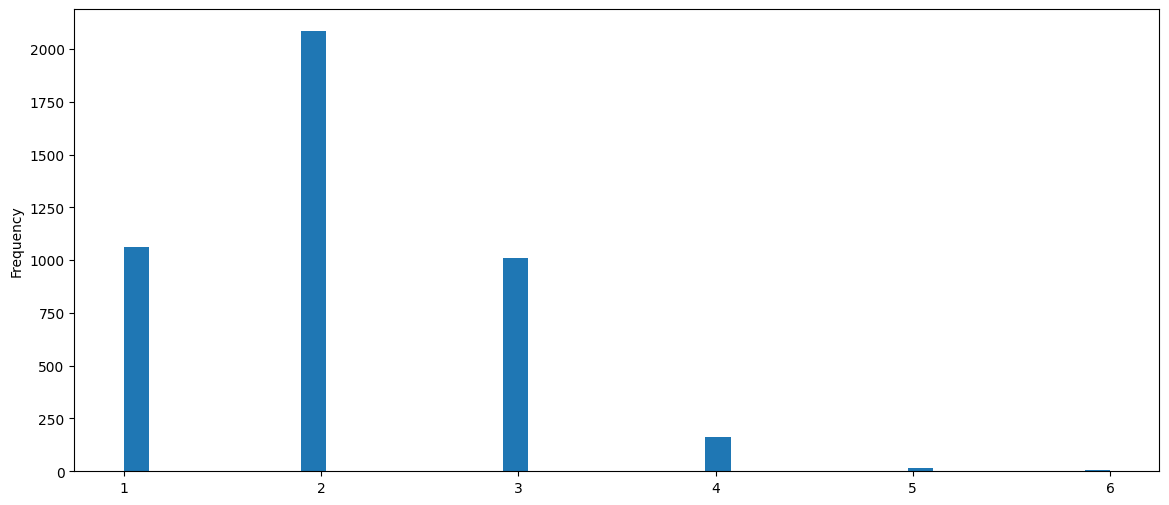

In [305]:
ax = df['BHK'].plot(kind='hist',    # тип діаграми hist
                             bins=39,        # кількість стовпчиків
                             figsize=(14,6)  # розмір зображення(в дюймах)
                             )

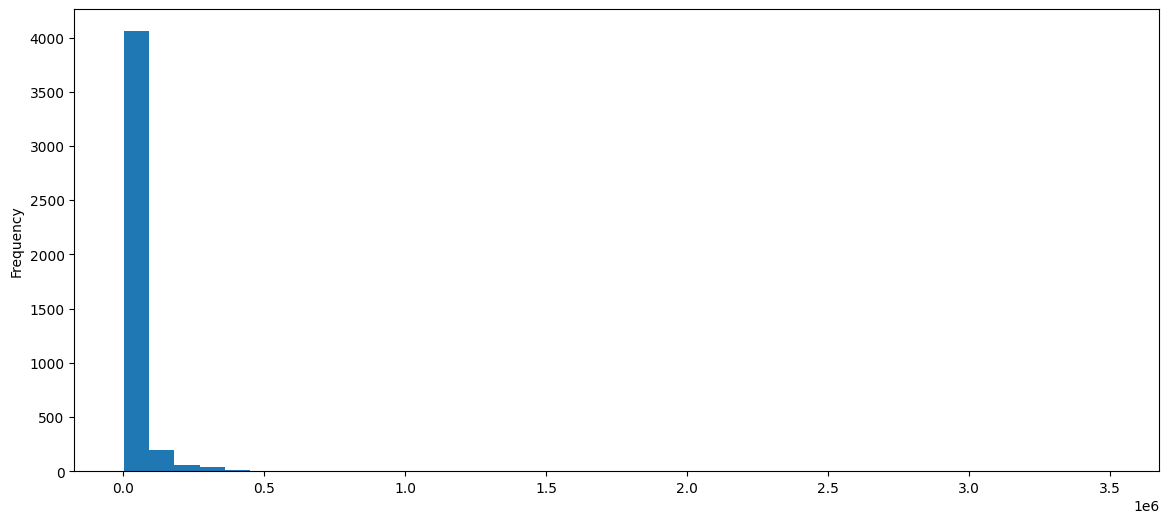

In [306]:
ax = df['Rent'].plot(kind='hist',    # тип діаграми hist
                             bins=39,        # кількість стовпчиків
                             figsize=(14,6)  # розмір зображення(в дюймах)
                             )

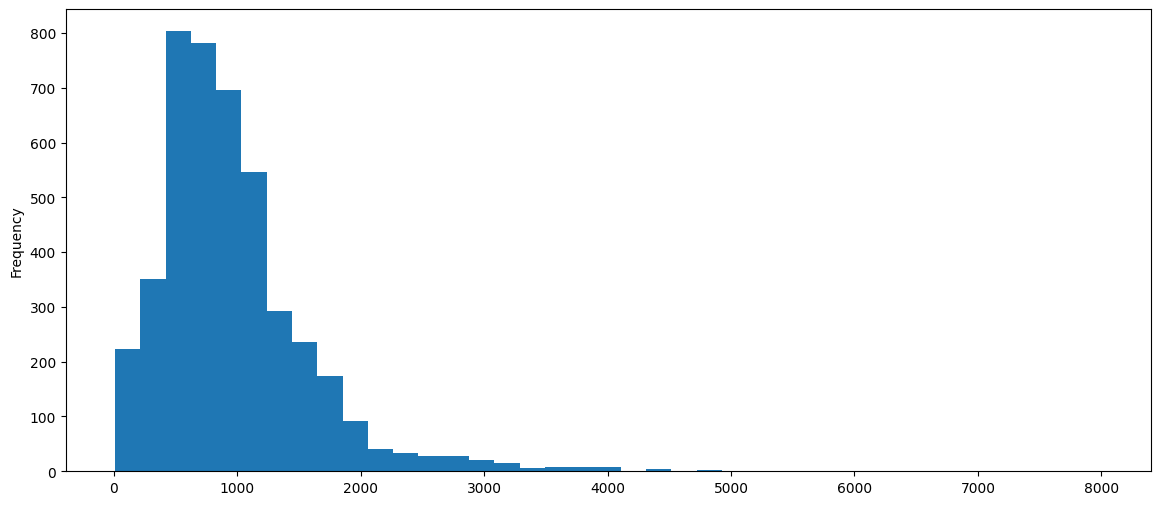

In [307]:
ax = df['Size'].plot(kind='hist',    # тип діаграми hist
                             bins=39,        # кількість стовпчиків
                             figsize=(14,6)  # розмір зображення(в дюймах)
                             )

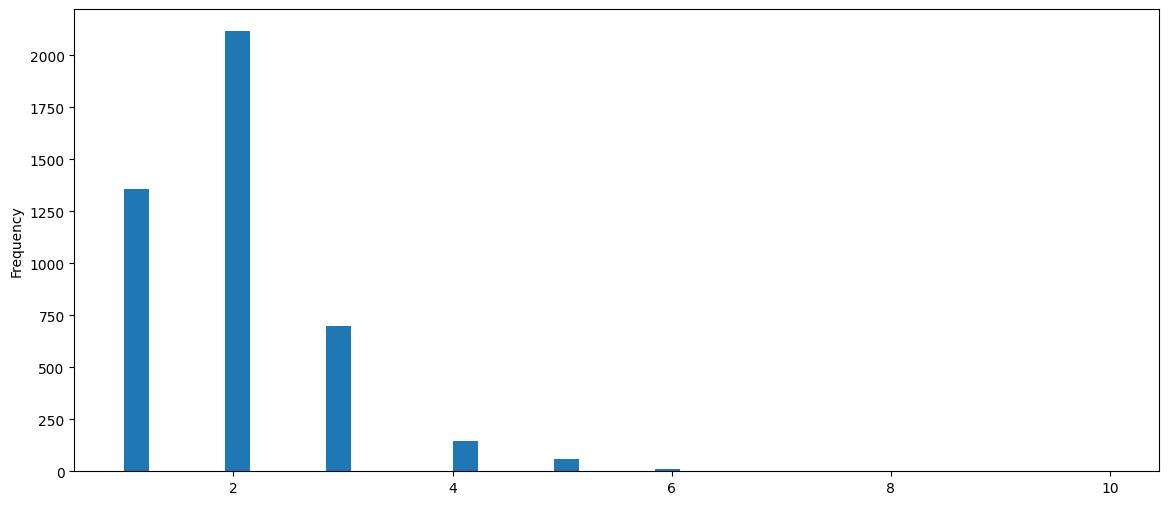

In [308]:
ax = df['Bathroom'].plot(kind='hist',    # тип діаграми hist
                             bins=39,        # кількість стовпчиків
                             figsize=(14,6)  # розмір зображення(в дюймах)
                             )

# Завдання 3
Виведіть ящик з вусами для всіх числових стовпчиків. Де потрібно очистіть викиди

<Axes: >

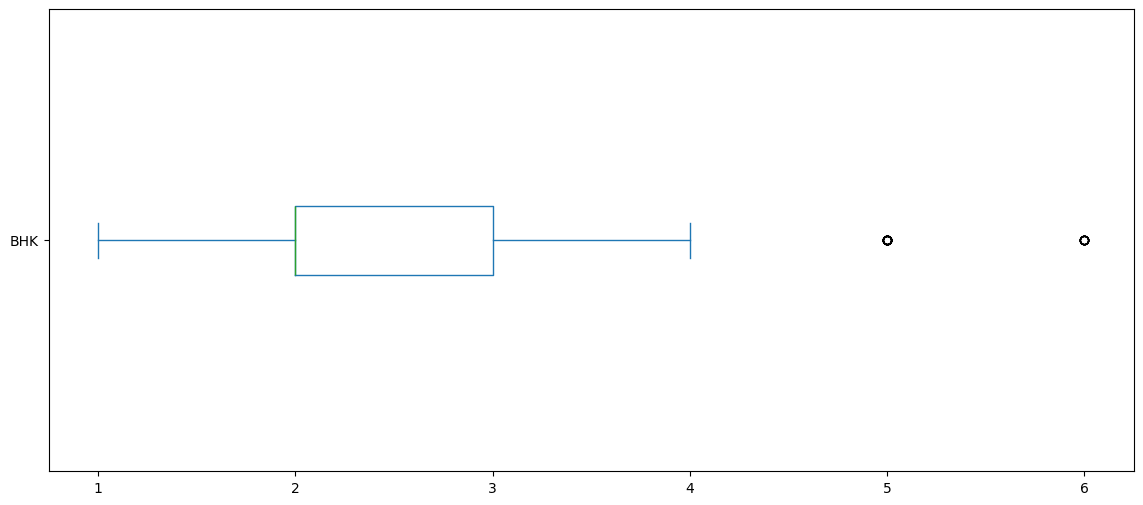

In [309]:
df['BHK'].plot(kind='box', vert=False, figsize=(14,6))

<Axes: >

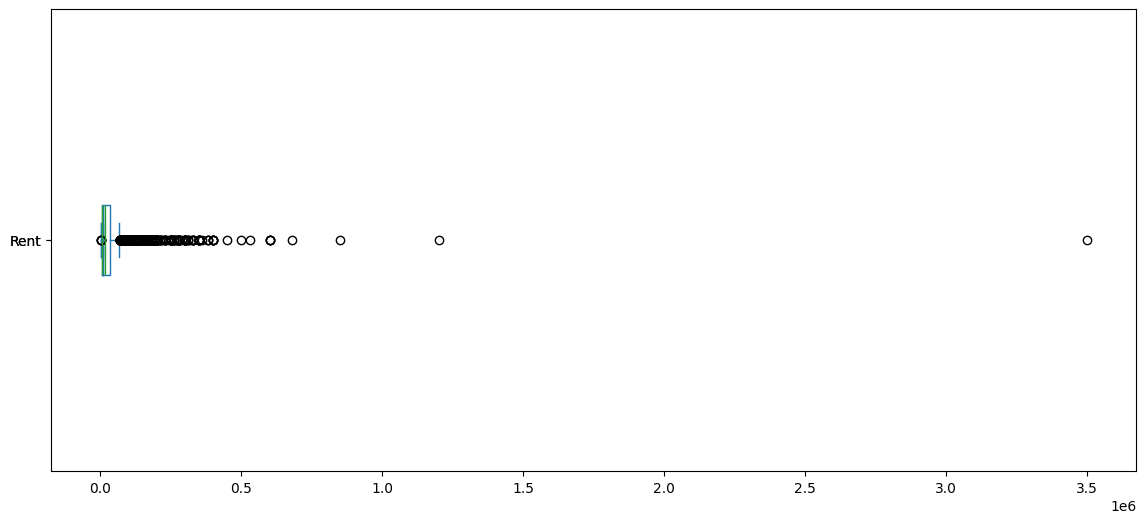

In [310]:
df['Rent'].plot(kind='box', vert=False, figsize=(14,6))
mask = df['Rent'] < 10000 # создание маски для чистки данных
mask.sum()
df = df[mask]
df['Rent'].plot(kind='box', vert=False, figsize=(14,6))

<Axes: >

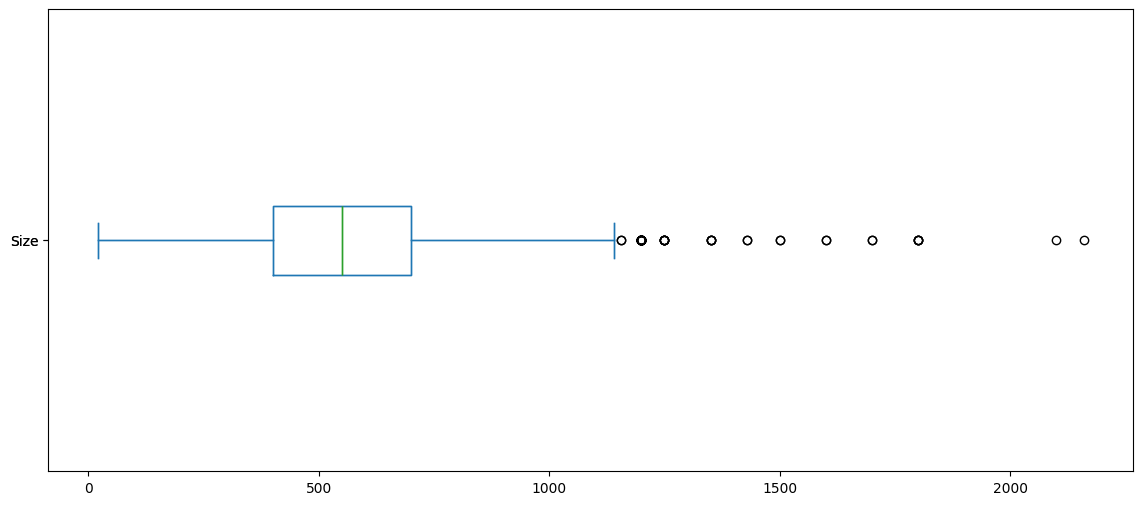

In [311]:
df['Size'].plot(kind='box', vert=False, figsize=(14,6))
mask = df['Size'] < 2000
mask.sum()
df = df[mask]
df['Size'].plot(kind='box', vert=False, figsize=(14,6))

<Axes: >

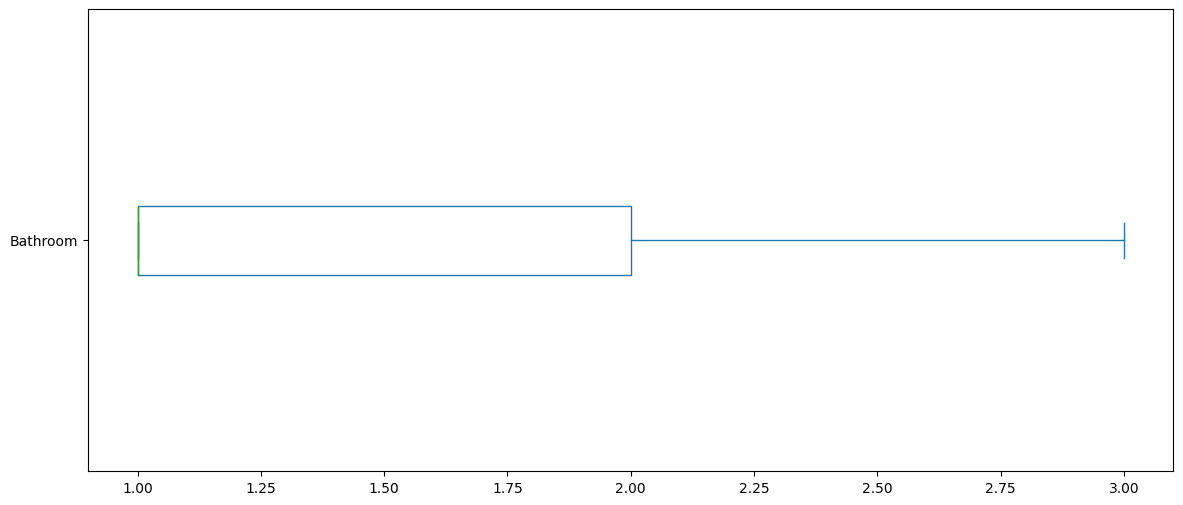

In [312]:
df['Bathroom'].plot(kind='box', vert=False, figsize=(14,6))

# Завдання 4
Створіть Pipeline для обробки даних

In [313]:
# импорт библиотек
import matplotlib.pyplot as plt
from sklearn import model_selection
from sklearn import tree
import graphviz

In [314]:
# обозначение датасетов
y = df['Rent']
X = df.drop(columns='Rent')

In [315]:
# разделение датасетов
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    train_size=0.8,
                                                    random_state=42
                                                    )

X_train.shape, X_test.shape

((737, 9), (185, 9))

In [316]:
# только числовые данные в основной таблице
num_cols_names = X.select_dtypes('number').columns
num_cols_names

Index(['BHK', 'Size', 'Bathroom'], dtype='object')

In [317]:
# только категориальные данные в основной таблице
cat_cols_names = X.select_dtypes('object').columns
cat_cols_names

Index(['Floor', 'Area Type', 'City', 'Furnishing Status', 'Tenant Preferred',
       'Point of Contact'],
      dtype='object')

In [318]:
# работа с sklearn
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

In [319]:
# трансормирование числовых данных для заполнения пропусков медианой
num_transformer = Pipeline([
    ('imput', SimpleImputer(strategy='median'))
])

In [320]:
# трансормирование категориальных данных для заполнения пропусков чаще всего втречаемым значением
cat_transformer = Pipeline([
    ('most_freq', SimpleImputer(strategy='most_frequent')),
    ('change_to_number', OneHotEncoder(sparse_output=False, handle_unknown='ignore'))
])


In [321]:
# соединение трансформированных данных в препроцессор
preprocessor = ColumnTransformer([
    ('nums', num_transformer, num_cols_names),
    ('cat', cat_transformer, cat_cols_names),
])

preprocessor

ColumnTransformer(transformers=[('nums',
                                 Pipeline(steps=[('imput',
                                                  SimpleImputer(strategy='median'))]),
                                 Index(['BHK', 'Size', 'Bathroom'], dtype='object')),
                                ('cat',
                                 Pipeline(steps=[('most_freq',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('change_to_number',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 Index(['Floor', 'Area Type', 'City', 'Furnishing Status', 'Tenant Preferred',
       'Point of Contact'],
      dtype='object'))])

In [322]:
preprocessor.set_output(transform='pandas')

ColumnTransformer(transformers=[('nums',
                                 Pipeline(steps=[('imput',
                                                  SimpleImputer(strategy='median'))]),
                                 Index(['BHK', 'Size', 'Bathroom'], dtype='object')),
                                ('cat',
                                 Pipeline(steps=[('most_freq',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('change_to_number',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 Index(['Floor', 'Area Type', 'City', 'Furnishing Status', 'Tenant Preferred',
       'Point of Contact'],
      dtype='object'))])

In [323]:
# запуск препроцессора для обработки значений
preprocessor.fit(X_train)
preprocessor.transform(X_train)

,nums__BHK,nums__Size,nums__Bathroom,cat__Floor_1 out of 1,cat__Floor_1 out of 2,cat__Floor_1 out of 3,cat__Floor_1 out of 4,cat__Floor_1 out of 5,cat__Floor_1 out of 6,cat__Floor_19 out of 20,...,cat__City_Mumbai,cat__Furnishing Status_Furnished,cat__Furnishing Status_Semi-Furnished,cat__Furnishing Status_Unfurnished,cat__Tenant Preferred_Bachelors,cat__Tenant Preferred_Bachelors/Family,cat__Tenant Preferred_Family,cat__Point of Contact_Contact Agent,cat__Point of Contact_Contact Builder,cat__Point of Contact_Contact Owner
2292,1.0,600.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
4170,2.0,103.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
46,2.0,400.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
170,1.0,190.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
22,1.0,300.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
219,2.0,550.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0
1092,1.0,200.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
4471,1.0,750.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
2216,2.0,550.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0


In [324]:
X_train.describe(include=["object"])

,Floor,Area Type,City,Furnishing Status,Tenant Preferred,Point of Contact
count,686,675,674,690,682,684
unique,43,2,6,3,3,3
top,1 out of 2,Super Area,Kolkata,Unfurnished,Bachelors/Family,Contact Owner
freq,103,449,196,382,580,625


In [325]:
# запуск модели
from sklearn.tree import DecisionTreeRegressor

full_model = Pipeline([
    ('prep', preprocessor),
    ('tree', DecisionTreeRegressor(max_depth=10))
])

full_model.fit(X_train, y_train)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('nums',
                                                  Pipeline(steps=[('imput',
                                                                   SimpleImputer(strategy='median'))]),
                                                  Index(['BHK', 'Size', 'Bathroom'], dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('most_freq',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('change_to_number',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  Index(['Floor', 'Area Type', 'City', 'Furnishing Status', 'Tenant Preferred',
       'Point of Contact'],
      dtype='object'))])),
                ('tree', DecisionTreeRegressor(max_depth=10))])

In [326]:
# сравнение данных с результатами модели
prices = full_model.predict(df)
df['model_result'] = prices
df

,BHK,Rent,Size,Floor,Area Type,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact,model_result
4,2.0,7500.0,850.0,1 out of 2,Carpet Area,Kolkata,Unfurnished,Bachelors,1.0,Contact Owner,7750.000000
5,2.0,7000.0,600.0,Ground out of 1,Super Area,Kolkata,Unfurnished,Bachelors/Family,2.0,Contact Owner,6800.000000
7,1.0,5000.0,250.0,1 out of 2,Super Area,NaN,Unfurnished,Bachelors,1.0,Contact Agent,4480.000000
11,1.0,5000.0,400.0,1 out of 1,Carpet Area,Kolkata,NaN,Bachelors/Family,1.0,Contact Agent,6152.272727
12,1.0,6500.0,250.0,1 out of 4,Carpet Area,NaN,NaN,Bachelors,1.0,Contact Owner,6500.000000
...,...,...,...,...,...,...,...,...,...,...,...
4706,1.0,4500.0,50.0,4 out of 5,Super Area,NaN,Unfurnished,Bachelors/Family,NaN,Contact Owner,5000.000000
4721,1.0,5500.0,40.0,Ground out of 2,Super Area,Hyderabad,Unfurnished,Bachelors/Family,1.0,Contact Owner,5500.000000
4730,2.0,8000.0,600.0,1 out of 4,Super Area,Hyderabad,NaN,Bachelors/Family,2.0,Contact Owner,8110.000000
4732,2.0,7000.0,900.0,Ground out of 2,Super Area,Hyderabad,Unfurnished,Bachelors/Family,1.0,Contact Owner,6796.709677


In [327]:
# процент точности
full_model.score(X_train, y_train)

0.7192818661406015

In [330]:
dot_data = tree.export_graphviz(full_model['tree'], out_file=None, feature_names = full_model['tree'].feature_names_in_) # вказуємо назви стовпчиків

graph = graphviz.Source(dot_data)
graph.render("diamond tree")
from google.colab import files
files.download("diamond tree.pdf")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>